In [1]:
import gzip
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import os
import re
import shutil
import sys

from sklearn import metrics
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [2]:
from scipy.stats import spearmanr

## Clustering traits based phenotypic correlation data

Here, we will use  the file generated by PhenoSpD analysis for the set 906 traits with significant clumping results to generate clusters of correlated traits.

In [11]:
gencorr = pd.read_csv('/mnt/data/phenome_proj/finngen/phenospd/fg_output_corr.txt', sep='\t', header=None)

In [5]:
!head -n1 /mnt/data/phenome_proj/finngen/phenospd/PhenoSpD_input.txt | cut -d ',' -f 4- | awk -F ',' '{ for (i=1;i<=NF;i++) print $i }' | grep -P '_b$' | perl -pe 's|_b||' | perl -pe 's|\.|_|g' > /mnt/data/phenome_proj/finngen/phenospd/phenospd_names.txt

In [12]:
clean_pheno_names = []
with open('/mnt/data/phenome_proj/finngen/phenospd/phenospd_names.txt', 'r') as tnf:
    for line in tnf:
        clean_pheno_names.append(line.strip())

len(clean_pheno_names)

906

In [13]:
gencorr.columns = clean_pheno_names
gencorr.index = clean_pheno_names
gencorr.head()

,AB1_BACTINF_NOS,AB1_BACT_INTEST_OTH,AB1_EBV,AB1_ERYSIPELAS,AB1_GASTROENTERITIS_NOS,AB1_INTESTINAL_INFECTIONS,AB1_LYME,AB1_OTHER_BACTERIAL,AB1_OTHER_SEPSIS,AB1_OTHER_SPIROCHAETAL,...,VD_MI,VD_MX,VD_SC,VD_U,WEIGHT_IRN,WET_AMD,YERSINIAENTERITIS,Z21_KIDNEY_TRANSPLANT_STATUS,Z21_PROBL_RELATED_MEDICAL_FACILITI_OTH_HEALTH_CARE,Z21_PROCREATIVE_MANAG
AB1_BACTINF_NOS,1.000000,0.129449,0.007016,0.262510,0.126086,0.138938,-0.001116,0.679565,0.318149,-0.000163,...,0.008596,0.017860,0.019762,0.018033,0.075499,0.018880,0.015578,0.085997,0.027958,0.019474
AB1_BACT_INTEST_OTH,0.129449,1.000000,0.018384,0.062019,0.200512,0.393678,0.002021,0.115513,0.095874,0.001724,...,0.001134,0.005452,0.011344,0.022424,0.014847,0.018189,0.149594,0.039900,0.003962,0.007717
AB1_EBV,0.007016,0.018384,1.000000,0.009659,0.028192,0.031362,0.012817,0.010001,-0.004820,0.014559,...,0.008943,-0.007828,-0.000224,0.015735,0.002631,0.003686,0.000357,0.012244,0.005034,0.011273
AB1_ERYSIPELAS,0.262510,0.062019,0.009659,1.000000,0.087910,0.095715,-0.002440,0.737569,0.255966,-0.002086,...,0.013916,0.006924,0.015530,0.025349,0.238151,0.023496,0.014409,0.063516,0.022928,0.001439
AB1_GASTROENTERITIS_NOS,0.126086,0.200512,0.028192,0.087910,1.000000,0.878843,-0.000072,0.144914,0.114787,0.000825,...,0.013692,0.002530,0.009750,0.015076,0.018719,0.029048,0.018702,0.071157,0.026001,0.024434


In [14]:
dist_rg = 1 - gencorr
dist_rg.head()

,AB1_BACTINF_NOS,AB1_BACT_INTEST_OTH,AB1_EBV,AB1_ERYSIPELAS,AB1_GASTROENTERITIS_NOS,AB1_INTESTINAL_INFECTIONS,AB1_LYME,AB1_OTHER_BACTERIAL,AB1_OTHER_SEPSIS,AB1_OTHER_SPIROCHAETAL,...,VD_MI,VD_MX,VD_SC,VD_U,WEIGHT_IRN,WET_AMD,YERSINIAENTERITIS,Z21_KIDNEY_TRANSPLANT_STATUS,Z21_PROBL_RELATED_MEDICAL_FACILITI_OTH_HEALTH_CARE,Z21_PROCREATIVE_MANAG
AB1_BACTINF_NOS,0.000000,0.870551,0.992984,0.737490,0.873914,0.861062,1.001116,0.320435,0.681851,1.000163,...,0.991404,0.982140,0.980238,0.981967,0.924501,0.981120,0.984422,0.914003,0.972042,0.980526
AB1_BACT_INTEST_OTH,0.870551,0.000000,0.981616,0.937981,0.799488,0.606322,0.997979,0.884487,0.904126,0.998276,...,0.998866,0.994548,0.988656,0.977576,0.985153,0.981811,0.850406,0.960100,0.996038,0.992283
AB1_EBV,0.992984,0.981616,0.000000,0.990341,0.971808,0.968638,0.987183,0.989999,1.004820,0.985441,...,0.991057,1.007828,1.000224,0.984265,0.997369,0.996314,0.999643,0.987756,0.994966,0.988727
AB1_ERYSIPELAS,0.737490,0.937981,0.990341,0.000000,0.912090,0.904285,1.002440,0.262431,0.744034,1.002086,...,0.986084,0.993076,0.984470,0.974651,0.761849,0.976504,0.985591,0.936484,0.977072,0.998561
AB1_GASTROENTERITIS_NOS,0.873914,0.799488,0.971808,0.912090,0.000000,0.121157,1.000072,0.855086,0.885213,0.999175,...,0.986308,0.997470,0.990250,0.984924,0.981281,0.970952,0.981298,0.928843,0.973999,0.975566


In [15]:
clustering = AgglomerativeClustering(n_clusters=2, affinity='precomputed',
            compute_full_tree=True, memory='tmp', linkage='average').fit(dist_rg)

scores = []
for i in range(50, round(0.8 * len(clean_pheno_names)), 1):
#     start_time = time.time()
    
    i = int(i)
    clustering.set_params(n_clusters=i)
    clusters = clustering.fit_predict(dist_rg)
    score = silhouette_score(dist_rg, clusters)
    scores.append(score)
    if i % 10 == 0:
        print(f'{i}: {score:.4f}')
#     print(f'{time.time() - start_time:.4f}')

50: -0.0886
60: -0.0478
70: -0.0387
80: -0.0135
90: 0.0065
100: 0.0125
110: 0.0270
120: 0.0514
130: 0.0610
140: 0.0607
150: 0.0868
160: 0.1004
170: 0.1194
180: 0.1234
190: 0.1314
200: 0.1391
210: 0.1492
220: 0.1557
230: 0.1580
240: 0.1628
250: 0.1714
260: 0.1753
270: 0.1811
280: 0.1966
290: 0.2066
300: 0.2103
310: 0.2150
320: 0.2216
330: 0.2223
340: 0.2285
350: 0.2351
360: 0.2412
370: 0.2430
380: 0.2451
390: 0.2548
400: 0.2526
410: 0.2548
420: 0.2591
430: 0.2573
440: 0.2586
450: 0.2568
460: 0.2587
470: 0.2564
480: 0.2629
490: 0.2627
500: 0.2612
510: 0.2601
520: 0.2601
530: 0.2572
540: 0.2568
550: 0.2542
560: 0.2536
570: 0.2553
580: 0.2502
590: 0.2526
600: 0.2486
610: 0.2457
620: 0.2393
630: 0.2309
640: 0.2260
650: 0.2138
660: 0.2020
670: 0.1988
680: 0.1945
690: 0.1932
700: 0.1883
710: 0.1787
720: 0.1758


In [16]:
optimal_n = np.argmax(scores) + 50
optimal_n

491

In [17]:
clustering.set_params(n_clusters=optimal_n)
clusters = clustering.fit_predict(dist_rg)

## Fine-mapping based analysis

This section covers the analysis part that involves SuSIE fine mapping results that are provided directly by FinnGen.

In [20]:
work_dir = '/mnt/data/phenome_proj/finngen/susie/'

In [21]:
fg_files = [x for x in os.listdir(work_dir) if '.cred.sum' in x]

In [35]:
fg_files = [x for x in fg_files if x.split('.')[0].replace('finngen_R12_', '') in clean_pheno_names]
fg_fm_phenos = [x.split('.')[0].replace('finngen_R12_', '') for x in fg_files if x.split('.')[0].replace('finngen_R12_', '') in clean_pheno_names]

In [114]:
fg_fm_phenos[0]

'N14_FEMALEINFERT'

In [27]:
len(fg_files)

824

In [107]:
fg_files[0]

'finngen_R12_N14_FEMALEINFERT.SUSIE.cred.summary.tsv'

In [148]:
group_by_icd = False

matched_traits = []
icd_parent_codes = set()
for susie_fname in fg_files:
    trait_name = susie_fname.split('.')[0].replace('finngen_R12_', '')
    if trait_name in ['BMI_IRN', 'HEIGHT_IRN', 'WEIGHT_IRN']:
            continue
    if group_by_icd:
        name_elements = susie_fname.split('_')
        if re.search("^[A-Z]+\d+$", name_elements[2]):
            icd_parent_codes.add(name_elements[2])
    matched_traits.append(trait_name)
icd_code_index = {val: idx for idx, val in enumerate(icd_parent_codes)}
print(len(matched_traits))

821


In [149]:
if group_by_icd:
    # Alternative way with ICD-10 codes
    genes = defaultdict(lambda: list(np.zeros(len(icd_parent_codes))))
    for idx, trait_name in enumerate(matched_traits):
        susie_fname = f'finngen_R12_{trait_name}.SUSIE.cred.summary.tsv'
        icd_code = susie_fname.split('_')[2]
        if icd_code not in icd_parent_codes:
            continue
        this_icd_idx = icd_code_index[icd_code]
        gene_list = pd.read_csv(f'{work_dir}/{susie_fname}', sep='\t')['gene_most_severe']
        for gene in gene_list:
            if isinstance(gene, str):
                genes[gene][this_icd_idx] = 1
else:
    genes = defaultdict(lambda: list(np.zeros(len(matched_traits))))
    for idx, trait_name in enumerate(matched_traits):
        susie_fname = f'finngen_R12_{trait_name}.SUSIE.cred.summary.tsv'
        gene_list = pd.read_csv(f'{work_dir}/{susie_fname}', sep='\t')['gene_most_severe']
        for gene in gene_list:
            if isinstance(gene, str):
                genes[gene][idx] = 1

In [150]:
len(genes)

4980

<AxesSubplot:ylabel='Count'>

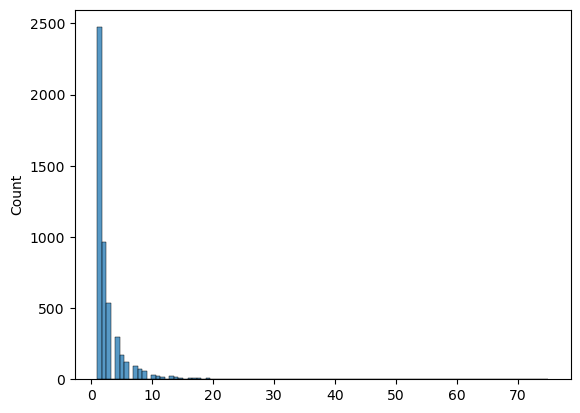

In [151]:
sns.histplot(pd.Series([sum(genes[x]) for x in genes]), bins=100)

In [152]:
assoc_counts = [sum(genes[x]) for x in genes]
for i in range(20):
    print(f'{i}: {len([x for x in assoc_counts if x > i])}')

0: 4980
1: 2507
2: 1540
3: 1005
4: 707
5: 539
6: 421
7: 330
8: 258
9: 203
10: 175
11: 151
12: 133
13: 107
14: 90
15: 80
16: 69
17: 57
18: 46
19: 34


In [153]:
all_genes = list(genes.values())
gene_matrix = np.array([x for x in all_genes])
gene_matrix

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [154]:
merged = []
for i in range(optimal_n):
    pheno_names = [clean_pheno_names[idx] for idx, n in enumerate(clusters) if n == i]
    pheno_idx = [idx for idx, pheno_name in enumerate(matched_traits) if pheno_name in pheno_names]
    gene_cluster = np.apply_along_axis(lambda x: 1 if 1 in x else 0, 1, gene_matrix[:,pheno_idx])
    merged.append(gene_cluster)
gene_cluster_matrix = np.array(merged).T
gene_cluster_matrix.shape

(4980, 491)

In [155]:
for i in range(20):
    print(f'{i}: {Counter(np.apply_along_axis(lambda x: 1 if sum(x) > i else 0, 1, gene_cluster_matrix))[1]}')

0: 4980
1: 1687
2: 802
3: 438
4: 269
5: 175
6: 126
7: 90
8: 70
9: 45
10: 32
11: 24
12: 20
13: 14
14: 11
15: 11
16: 11
17: 11
18: 9
19: 7


In [156]:
gene_info = pd.read_csv('/mnt/data/phenome_proj/network_cleanup/gencode_formatted.bed', sep='\t', header=None)
gene_info.columns = ['chrom', 'start', 'end', 'gene_name']
gene_info.head()

,chrom,start,end,gene_name
0,1,11869,14412,DDX11L1
1,1,14363,29806,WASH7P
2,1,29554,31109,MIR1302-11
3,1,34554,36081,FAM138A
4,1,52473,54936,OR4G4P


In [157]:
gene_info.shape

(57820, 4)

In [158]:
gene_info = gene_info.drop_duplicates('gene_name')
gene_info.shape

(55765, 4)

In [159]:
annot_genes = set(gene_info['gene_name'])

In [160]:
Counter([x in annot_genes for x in list(genes.keys())])

Counter({False: 1050, True: 3930})

In [161]:
fg_pleio_data = pd.DataFrame({'gene_name': list(genes.keys()), 
                             'fg_pleio_degree': list([sum(gene_cluster_matrix[x]) for x, _ in enumerate(genes.keys())])})
fg_pleio_data.head()

,gene_name,fg_pleio_degree
0,AL031281.2,4
1,SYNE1,5
2,GREB1,5
3,COL23A1,1
4,PKHD1L1,1


In [162]:
gene_info = gene_info.merge(fg_pleio_data, on='gene_name', how='outer')
gene_info.head()

,chrom,start,end,gene_name,fg_pleio_degree
0,1,11869.0,14412.0,DDX11L1,NaN
1,1,14363.0,29806.0,WASH7P,NaN
2,1,29554.0,31109.0,MIR1302-11,NaN
3,1,34554.0,36081.0,FAM138A,NaN
4,1,52473.0,54936.0,OR4G4P,NaN


In [163]:
sum(gene_info['fg_pleio_degree'] > 0)

4980

In [164]:
gene_info = gene_info[gene_info['fg_pleio_degree'] > 0]
gene_info.head()

,chrom,start,end,gene_name,fg_pleio_degree
86,1,1108436.0,1114935.0,TTLL10-AS1,1.0
90,1,1152288.0,1167411.0,SDF4,1.0
97,1,1227756.0,1244989.0,ACAP3,1.0
103,1,1270656.0,1284730.0,DVL1,2.0
104,1,1288069.0,1297157.0,MXRA8,1.0


In [165]:
pan_ukb_data = pd.read_csv('/mnt/data/phenome_proj/evolution/non_hla_panukb_pleiotropy_allTypes.tsv', sep='\t')
pan_ukb_data.head()

,gene_name,pleio_degree,pleio_degree_maxindep,pleio_degree_locuswide
0,RP3-469D22.1,NaN,NaN,7.0
1,AL031284.1,NaN,NaN,7.0
2,RHCE,6.0,2.0,7.0
3,TMEM57,5.0,6.0,7.0
4,TMEM61,NaN,NaN,1.0


In [166]:
all_gwas_data = gene_info.merge(pan_ukb_data, on='gene_name', how='outer')
all_gwas_data.shape

(19338, 8)

In [167]:
all_gwas_data['fg_pleio_degree'] = all_gwas_data['fg_pleio_degree'].replace({0: np.nan})

In [168]:
all_gwas_data.head()

,chrom,start,end,gene_name,fg_pleio_degree,pleio_degree,pleio_degree_maxindep,pleio_degree_locuswide
0,1,1108436.0,1114935.0,TTLL10-AS1,1.0,NaN,NaN,1.0
1,1,1152288.0,1167411.0,SDF4,1.0,NaN,NaN,NaN
2,1,1227756.0,1244989.0,ACAP3,1.0,NaN,NaN,1.0
3,1,1270656.0,1284730.0,DVL1,2.0,NaN,NaN,1.0
4,1,1288069.0,1297157.0,MXRA8,1.0,NaN,NaN,1.0


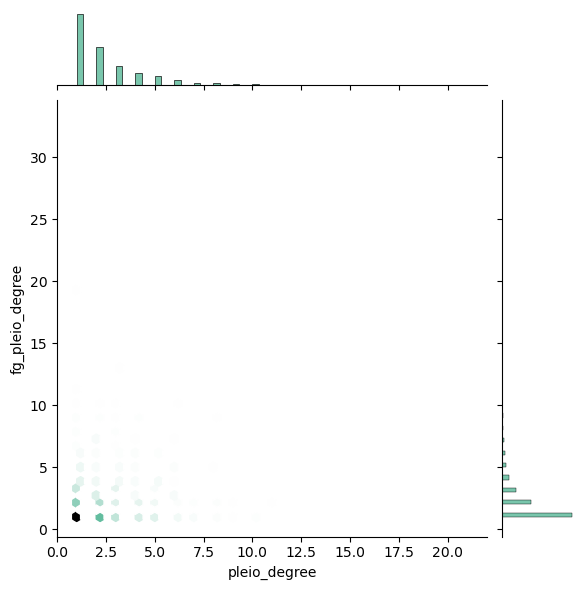

In [169]:
sns.jointplot(x=all_gwas_data['pleio_degree'], y=all_gwas_data['fg_pleio_degree'], 
              kind="hex", color="#4CB391")

In [170]:
spearmanr(all_gwas_data['pleio_degree'], all_gwas_data['fg_pleio_degree'], nan_policy='omit')

SpearmanrResult(correlation=0.2114724029445923, pvalue=1.5053116922218533e-18)

In [171]:
def hla_checker(gene_idx, gene_meta=all_gwas_data):
    try:
        this_gene = gene_meta.iloc[gene_idx]
#        print(this_gene)
    except:
        print(f'Error at idx {gene_idx}')
    if str(this_gene['chrom']) == '6' and this_gene['start'] > 27500000 and this_gene['end'] < 35000000:
        return False
    else:
#        print(type(this_gene['chr']))
        return True

In [172]:
Counter([hla_checker(x) for x in range(all_gwas_data.shape[0])])

Counter({True: 19329, False: 9})

In [173]:
all_gwas_non_hla = all_gwas_data.loc[[hla_checker(x) for x in range(all_gwas_data.shape[0])]]
all_gwas_non_hla.shape

(19329, 8)

In [174]:
all_gwas_non_hla.to_csv('/mnt/data/phenome_proj/evolution/non_hla_panukb_finngen_pleiotropy.tsv', sep='\t',
                       index=False)

## Closest gene-based analysis branch

Here, we attempt to use the strategy based on closest genes (the one that is similar to that used for pan-UKB data processing).

The coordinate conversion and clumping part has been performed using the `batch_process.sh` and `process_file.sh` scripts.

Below, we will perform gene inference and matrix construction.

In [65]:
import subprocess as sp

In [175]:
data_dir = '/mnt/data/phenome_proj/finngen/clumping/'
file_list = os.listdir(data_dir)
file_list = [x for x in file_list if x.endswith('.clumped')]

In [176]:
len(file_list)

906

In [177]:
file_list[0]

'finngen_R12_I9_CEREBAMY.clump.clumped'

In [210]:
def create_gene_bed(clump_file, work_dir=data_dir, data_dir=data_dir):
    bed_cmd = f'''awk 'OFS="\t" {{ print $1,$4,$4+1,$3,$5 }}' {data_dir}/{clump_file} \
                         | sort -k1,1 -k2,2n | grep -vP '^\s+|CHR' > {work_dir}/{clump_file}.lead.bed'''
    status = sp.run(bed_cmd, shell=True)
    gene_cmd = f'''bedtools closest -a {work_dir}/{clump_file}.lead.bed \
                                    -b /mnt/data/phenome_proj/network_cleanup/gencode_formatted.bed \
                                    > {work_dir}/{clump_file}.genes.bed'''
    status = sp.run(gene_cmd, shell=True)
    print(f'Done {clump_file}')

In [211]:
for clump_file in file_list:
    create_gene_bed(clump_file)

Done finngen_R12_I9_CEREBAMY.clump.clumped
Done finngen_R12_K11_IBD_STRICT_PSC.clump.clumped
Done finngen_R12_E4_PCOS.clump.clumped
Done finngen_R12_L12_SEBORRKERAT.clump.clumped
Done finngen_R12_CD2_BENIGN_PAROTID.clump.clumped
Done finngen_R12_H7_GLAUCOMA_POAG.clump.clumped
Done finngen_R12_M13_LUMBAR_PROLAPSE.clump.clumped
Done finngen_R12_M13_DORSOPATHY.clump.clumped
Done finngen_R12_H7_BLEPHAROCHALASIS.clump.clumped
Done finngen_R12_COPD_LATER.clump.clumped
Done finngen_R12_N14_PROSTHYPERPLA.clump.clumped
Done finngen_R12_H7_VITRBODYGLOBE.clump.clumped
Done finngen_R12_ABDOM_HERNIA.clump.clumped
Done finngen_R12_ALCOPANCCHRON.clump.clumped
Done finngen_R12_AB1_INTESTINAL_INFECTIONS.clump.clumped
Done finngen_R12_J10_CHRONSINUSITIS.clump.clumped
Done finngen_R12_I9_CHD.clump.clumped
Done finngen_R12_COPD_EARLY.clump.clumped
Done finngen_R12_RHEUMA_SEROPOS_STRICT.clump.clumped
Done finngen_R12_H8_VERTIGO.clump.clumped
Done finngen_R12_G6_ATROPHCIRCUM.clump.clumped
Done finngen_R12_Q

Done finngen_R12_CONGEN_HEART_ARTER.clump.clumped
Done finngen_R12_REITER.clump.clumped
Done finngen_R12_M13_MUSCLE.clump.clumped
Done finngen_R12_CD2_LYMPHOID_LEUKAEMIA_EXALLC.clump.clumped
Done finngen_R12_K11_LIVER.clump.clumped
Done finngen_R12_OTHER_SYSTCON_FG.clump.clumped
Done finngen_R12_F5_DELIRIUM.clump.clumped
Done finngen_R12_F5_ALLANXIOUS.clump.clumped
Done finngen_R12_K11_CHOLECYST.clump.clumped
Done finngen_R12_N14_ENDOMETRIOSIS_RECTPVAGSEPT_VAGINA.clump.clumped
Done finngen_R12_K11_OTHINFLIV.clump.clumped
Done finngen_R12_CD2_BENIGN_RECTUM.clump.clumped
Done finngen_R12_AB1_TUBERCULOSIS.clump.clumped
Done finngen_R12_E4_LACTONAS.clump.clumped
Done finngen_R12_F5_MOOD.clump.clumped
Done finngen_R12_E4_DYSPOLYGL.clump.clumped
Done finngen_R12_I9_PERICARD.clump.clumped
Done finngen_R12_Q17_CONGEN_MALFO_OVARIES_FALLOP_TUBES_BROAD_LIGAM.clump.clumped
Done finngen_R12_C3_BLADDER_EXALLC.clump.clumped
Done finngen_R12_J10_ASTHMACOPDKELA.clump.clumped
Done finngen_R12_Q17_VACTRE

Done finngen_R12_G6_MUSCOTHUNS.clump.clumped
Done finngen_R12_H7_RETIVASCOCCLUSION.clump.clumped
Done finngen_R12_MEMLOSS.clump.clumped
Done finngen_R12_I9_HEARTFAIL_AND_OVERWEIGHT.clump.clumped
Done finngen_R12_H7_GLAUCOMAMEDICATION.clump.clumped
Done finngen_R12_N14_CHRONKIDNEYDIS.clump.clumped
Done finngen_R12_N14_VULVAL_LSIL.clump.clumped
Done finngen_R12_CD2_HODGKIN_LYMPHOMA_EXALLC.clump.clumped
Done finngen_R12_CD2_PRIMARY_LYMPHOID_HEMATOPOIETIC_EXALLC.clump.clumped
Done finngen_R12_C3_COLORECTAL_EXALLC.clump.clumped
Done finngen_R12_CD2_BENIGN_COLORECANI.clump.clumped
Done finngen_R12_J10_BRONCHITIS.clump.clumped
Done finngen_R12_CD2_BENIGN_BRAIN_CNS.clump.clumped
Done finngen_R12_AB1_BACT_INTEST_OTH.clump.clumped
Done finngen_R12_AB1_WHOOPCOUGH.clump.clumped
Done finngen_R12_CD2_BENIGN_MENINGES.clump.clumped
Done finngen_R12_K11_ENERCOLNONINF.clump.clumped
Done finngen_R12_DERMATOPOLY_FG.clump.clumped
Done finngen_R12_O15_ABORT_MEDICAL.clump.clumped
Done finngen_R12_G6_MUSDYST.

Done finngen_R12_Q17_CLEFT_HARD_PALATE_NOS.clump.clumped
Done finngen_R12_L12_URTICA_NAS.clump.clumped
Done finngen_R12_I9_IHD.clump.clumped
Done finngen_R12_ILD_INSUFFICIENCY.clump.clumped
Done finngen_R12_M13_ARTHTROSIS_COX_PRIM_HIPSURG.clump.clumped
Done finngen_R12_M13_PALINDROMIC.clump.clumped
Done finngen_R12_BRONCHITIS.clump.clumped
Done finngen_R12_CD2_INSITU_BREAST_INTRADUCTAL_EXALLC.clump.clumped
Done finngen_R12_VD_MX.clump.clumped
Done finngen_R12_K11_OTHDIG.clump.clumped
Done finngen_R12_K11_HERNIA.clump.clumped
Done finngen_R12_HEIGHT_IRN.clump.clumped
Done finngen_R12_I9_SEQULAE.clump.clumped
Done finngen_R12_GOUT_STRICT.clump.clumped
Done finngen_R12_N14_MALEGEN.clump.clumped
Done finngen_R12_K11_ORAL_LICHEN_PLANUS.clump.clumped
Done finngen_R12_AD_LO_EXMORE.clump.clumped
Done finngen_R12_E4_NONTOXIC_THYROID.clump.clumped
Done finngen_R12_AB1_ZOSTER.clump.clumped
Done finngen_R12_E4_HYPERLIPMIX.clump.clumped
Done finngen_R12_L12_ROSACEANAS.clump.clumped
Done finngen_R12

Done finngen_R12_C3_BREAST_EXALLC.clump.clumped
Done finngen_R12_ASTHMA_CHILD_EXMORE.clump.clumped
Done finngen_R12_Q17_CONGEN_MALFO_CIRCULATO_SYSTEM.clump.clumped
Done finngen_R12_CD2_BENIGN_COLON.clump.clumped
Done finngen_R12_I9_VEINSOTH.clump.clumped
Done finngen_R12_L12_FOLLICULARCYST.clump.clumped
Done finngen_R12_L12_INFECT_SKIN.clump.clumped
Done finngen_R12_I9_DISVEINLYMPH.clump.clumped
Done finngen_R12_PD_DEMENTIA_EXMORE.clump.clumped
Done finngen_R12_AB1_VIRAL_SKIN_MUCOUS_MEMBRANE.clump.clumped
Done finngen_R12_L12_ULCERLOWLIMB.clump.clumped
Done finngen_R12_G6_MIGRAINE_WITH_AURA.clump.clumped
Done finngen_R12_Q17_ANKYLOGLOSSIA.clump.clumped
Done finngen_R12_C3_COLON_ADENO_EXALLC.clump.clumped
Done finngen_R12_M13_FIBROBLASTIC.clump.clumped
Done finngen_R12_M13_SPONDYLOPATHY.clump.clumped
Done finngen_R12_M13_GANGLION.clump.clumped
Done finngen_R12_G6_NEUATR.clump.clumped
Done finngen_R12_H8_EXTERNAL.clump.clumped
Done finngen_R12_O15_DELIV_PERIN_LACER.clump.clumped
Done fin

Done finngen_R12_CD2_BENIGN_LIPOMATOUS.clump.clumped
Done finngen_R12_M13_SCOLIOSIS.clump.clumped
Done finngen_R12_M13_ARTHTROSIS_COX_PRIM_ICD10.clump.clumped
Done finngen_R12_I9_STR.clump.clumped
Done finngen_R12_N14_ENDOMETRIOSIS_NOS.clump.clumped
Done finngen_R12_CD2_BENIGN_CAECUM.clump.clumped
Done finngen_R12_K11_CHOLECYSTECTOMY.clump.clumped
Done finngen_R12_M13_MYOSITIS.clump.clumped
Done finngen_R12_Q17_NEUROFIBROMATOSIS_2.clump.clumped
Done finngen_R12_M13_DORSALGIA.clump.clumped
Done finngen_R12_M13_ENTEROARTHR.clump.clumped
Done finngen_R12_O15_EXCESS_VOMIT_PREG.clump.clumped
Done finngen_R12_C3_KIDNEY_CLEAR_CELL_CARCINOMA_EXALLC.clump.clumped
Done finngen_R12_H7_CATARACTOTHER.clump.clumped
Done finngen_R12_RX_STATIN.clump.clumped
Done finngen_R12_I9_TIA.clump.clumped
Done finngen_R12_M13_ANKYLOSPON.clump.clumped
Done finngen_R12_H7_LACRIMALSYSTEM.clump.clumped
Done finngen_R12_F5_DEMENTIA_INCLAVO.clump.clumped
Done finngen_R12_N14_URETHRAOTH.clump.clumped
Done finngen_R12_F

In [64]:
#matched_traits = 0
#icd_parent_codes = set()
#for clump_file_name in file_list:
#    name_elements = clump_file_name.split('_')
#    if re.search("^[A-Z]+\d+$", name_elements[2]):
#        matched_traits += 1
#        icd_parent_codes.add(name_elements[2])
#icd_code_index = {val: idx for idx, val in enumerate(icd_parent_codes)}
#print(matched_traits)
#icd_parent_codes

In [180]:
genes = {}
group_by_icd = False
if group_by_icd:
    pheno_count = len(icd_parent_codes)
else:
    found_phenos = 0
    pheno_count = len(clean_pheno_names)

non_quant_traits  = [x for x in clean_pheno_names if x not in ['BMI_IRN', 'HEIGHT_IRN', 'WEIGHT_IRN']]
for idx, pheno in enumerate(non_quant_traits):
    in_file = f'{data_dir}/finngen_R12_{pheno}.clump.clumped.genes.bed'
    try:
        gene_data = pd.read_csv(in_file, sep='\t', header=None)
    except:
#        print('Broke here')
        continue
    if group_by_icd:
        name_elements = pheno.split('_')
        current_icd_code = name_elements[0]
        current_pheno_idx = icd_code_index[current_icd_code]
    else:
#        curr_pheno_name = pheno.split('.')[0].replace('finngen_R12_', '')
        current_pheno_idx = [idx for idx, pheno_name in enumerate(non_quant_traits) if pheno_name == pheno][0]
        found_phenos += 1
    gene_data.columns = ['var_chr', 'var_pos', 'var_end', 'rsid', 'pval', 'chr', 'start', 'end', 'gene_name']
    for chrom, start, end, symbol in zip(gene_data['chr'], gene_data['start'], 
                          gene_data['end'], gene_data['gene_name']):
        if symbol not in genes:
            genes[symbol] = [symbol, chrom, start, end] + [0 for x in range(len(non_quant_traits))]
        genes[symbol][current_pheno_idx + 4] = 1
print(len(genes))
print(genes['LRP1'])
print(len(genes['LRP1']))
if not group_by_icd:
    print(found_phenos)

6018
['LRP1', 12, 57522276, 57607134, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

<AxesSubplot:ylabel='Count'>

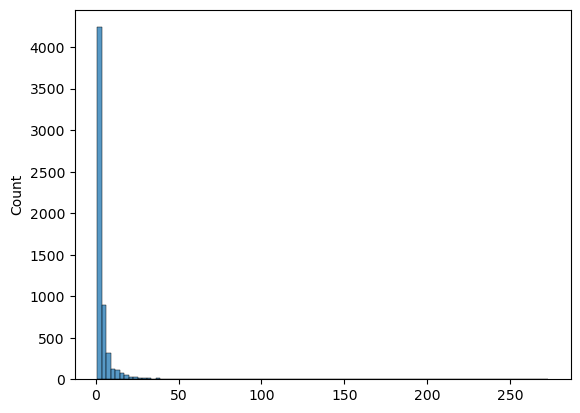

In [181]:
sns.histplot(pd.Series([sum(genes[x][4:]) for x in genes]), bins=100)

In [182]:
all_genes = list(genes.values())
gene_matrix = np.array([x[4:] for x in all_genes])
gene_matrix

array([[1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [184]:
merged = []
for i in range(optimal_n):
    pheno_names = [clean_pheno_names[idx] for idx, n in enumerate(clusters) if n == i]
    pheno_idx = [idx for idx, pheno_name in enumerate(non_quant_traits) if pheno_name in pheno_names]
    gene_cluster = np.apply_along_axis(lambda x: 1 if 1 in x else 0, 1, gene_matrix[:,pheno_idx])
    merged.append(gene_cluster)
gene_cluster_matrix = np.array(merged).T
gene_cluster_matrix.shape

(6018, 491)

In [185]:
gene_meta = {'gene_name': [x[0] for x in all_genes],
            'chr': [x[1] for x in all_genes],
            'start': [x[2] for x in all_genes],
            'end': [x[3] for x in all_genes]}
gene_meta = pd.DataFrame(gene_meta)
gene_meta.head()

,gene_name,chr,start,end
0,RP11-550P17.5,1,159315956,159438858
1,CRP,1,159682079,159684379
2,RP11-419N10.5,1,159728960,159729379
3,APOE,19,45409011,45412650
4,HLA-B,6,31321649,31324965


In [186]:
def hla_checker(gene_idx, gene_meta=gene_meta):
    try:
        this_gene = gene_meta.iloc[gene_idx]
#        print(this_gene)
    except:
        print(f'Error at idx {gene_idx}')
    if str(this_gene['chr']) == '6' and this_gene['start'] > 27500000 and this_gene['end'] < 35000000:
        return False
    else:
#        print(type(this_gene['chr']))
        return True

In [187]:
Counter([hla_checker(x) for x in range(len(gene_matrix))])

Counter({True: 5650, False: 368})

In [188]:
non_hla_genes = [idx for idx, gene in enumerate(gene_matrix) if hla_checker(idx)]
len(non_hla_genes)

5650

In [189]:
non_hla_matrix = gene_matrix[non_hla_genes, :]

In [190]:
non_hla_matrix.shape

(5650, 903)

In [191]:
non_hla_meta = gene_meta.iloc[non_hla_genes, :].copy()

In [192]:
non_hla_meta.shape

(5650, 4)

In [193]:
non_hla_meta['fg_pleio_degree_closest'] = np.apply_along_axis(sum, 1, non_hla_matrix)

In [194]:
non_hla_meta.head()

,gene_name,chr,start,end,fg_pleio_degree_closest
0,RP11-550P17.5,1,159315956,159438858,2
1,CRP,1,159682079,159684379,3
2,RP11-419N10.5,1,159728960,159729379,8
3,APOE,19,45409011,45412650,74
7,SERPINB9,6,2887500,2903514,1


In [195]:
all_gwas_data.shape

(19338, 8)

In [196]:
all_gwas_data_final = all_gwas_non_hla.merge(non_hla_meta, 
                                        on='gene_name', how='outer')

In [197]:
all_gwas_data_final.shape

(20822, 12)

In [198]:
all_gwas_data_final.chrom = all_gwas_data_final.chrom.astype('string')
all_gwas_data_final.chr = all_gwas_data_final.chr.astype('string')

In [199]:
all_gwas_data_final['start'] = [y if np.isnan(x) else x for x, y in zip(all_gwas_data_final['start_x'],
                all_gwas_data_final['start_y'])]
all_gwas_data_final['end'] = [y if np.isnan(x) else x for x, y in zip(all_gwas_data_final['end_x'],
                all_gwas_data_final['end_y'])]
all_gwas_data_final['chrom'] = [y if pd.isnull(x) else x for x, y in zip(all_gwas_data_final['chrom'],
                all_gwas_data_final['chr'])]
all_gwas_data_final = all_gwas_data_final.drop(['start_x', 'start_y', 'end_x', 'end_y', 'chr'],
                                          axis=1)
all_gwas_data_final.tail()

,chrom,gene_name,fg_pleio_degree,pleio_degree,pleio_degree_maxindep,pleio_degree_locuswide,fg_pleio_degree_closest,start,end
20817,6.0,RPL21P67,NaN,NaN,NaN,NaN,1.0,131790199.0,131790676.0
20818,7.0,PSMC2,NaN,NaN,NaN,NaN,1.0,102984701.0,103009842.0
20819,7.0,ZNF767,NaN,NaN,NaN,NaN,1.0,149244245.0,149321843.0
20820,7.0,KLHL7-AS1,NaN,NaN,NaN,NaN,1.0,23140847.0,23145322.0
20821,7.0,AC004014.4,NaN,NaN,NaN,NaN,1.0,108634088.0,108635086.0


In [200]:
all_gwas_data_final.head()

,chrom,gene_name,fg_pleio_degree,pleio_degree,pleio_degree_maxindep,pleio_degree_locuswide,fg_pleio_degree_closest,start,end
0,1,TTLL10-AS1,1.0,NaN,NaN,1.0,NaN,1108436.0,1114935.0
1,1,SDF4,1.0,NaN,NaN,NaN,NaN,1152288.0,1167411.0
2,1,ACAP3,1.0,NaN,NaN,1.0,3.0,1227756.0,1244989.0
3,1,DVL1,2.0,NaN,NaN,1.0,NaN,1270656.0,1284730.0
4,1,MXRA8,1.0,NaN,NaN,1.0,2.0,1288069.0,1297157.0


In [201]:
Counter([pd.isnull(x) for x in all_gwas_data_final['chrom']])

Counter({False: 7214, True: 13608})

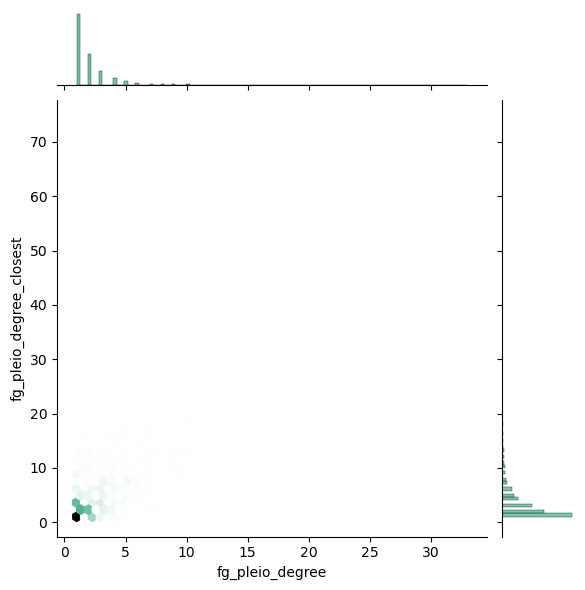

In [202]:
sns.jointplot(x=all_gwas_data_final['fg_pleio_degree'], 
              y=all_gwas_data_final['fg_pleio_degree_closest'], 
              kind="hex", color="#4CB391")

In [203]:
export_gwas = all_gwas_data_final.drop(['chrom', 'start', 'end'], axis=1)
export_gwas.shape

(20822, 6)

In [204]:
export_gwas.drop_duplicates('gene_name', inplace=True)
export_gwas.shape

(20822, 6)

### NB!

Here I rename the columns in the export data frame so that the main FinnGen data column contains closest gene data (and the fine-mapping based column has a different suffix).

This decision is motivated by exploratory analysis and comparison of the reulsts obtained using these two methods (closest gene-based method yields results that are more consistent with the pan-UKB analysis).

In [205]:
export_gwas = export_gwas.rename({'fg_pleio_degree': 'fg_pleio_degree_finemap',
                   'fg_pleio_degree_closest': 'fg_pleio_degree'}, axis=1)

In [206]:
export_gwas.to_csv('/mnt/data/phenome_proj/evolution/non_hla_panukb_finngen_pleiotropy_final.tsv', sep='\t', index=False)

### Exporting the bipartite network for modularity analysis

In [207]:
gene_matrix.shape

(6018, 903)

In [208]:
gene_cluster_matrix.shape

(6018, 491)

In [209]:
with open('/mnt/data/phenome_proj/evolution/finngen_closest_edgeList.txt', 'w') as net_file:
    if group_by_icd:
        edgelist_source = gene_matrix.copy()
    else:
        edgelist_source = gene_cluster_matrix.copy()
    for idx, row_data in enumerate(edgelist_source):
        for col_idx, assoc in enumerate(row_data):
            if assoc == 1:
                net_file.write(f'{idx}\t{col_idx}\n')

## Exporting list of traits for SI Table

In [210]:
fg_manifest = pd.read_csv('/mnt/data/phenome_proj/finngen/finngen_R12_manifest.tsv', sep='\t')
fg_manifest.head()

,phenocode,phenotype,category,num_cases,num_controls,path_bucket,path_https
0,AB1TUBERCU_MILIARY,Miliary tuberculosis,I Certain infectious and parasitic diseases (A...,60,497285,gs://finngen-public-data-r12/summary_stats/rel...,https://storage.googleapis.com/finngen-public-...
1,AB1_ACTINOMYCOSIS,Actinomycosis,I Certain infectious and parasitic diseases (A...,124,439048,gs://finngen-public-data-r12/summary_stats/rel...,https://storage.googleapis.com/finngen-public-...
2,AB1_AMOEBIASIS,Amoebiasis,I Certain infectious and parasitic diseases (A...,197,444292,gs://finngen-public-data-r12/summary_stats/rel...,https://storage.googleapis.com/finngen-public-...
3,AB1_ANOGENITAL_HERPES_SIMPLEX,Anogenital herpesviral [herpes simplex] infection,I Certain infectious and parasitic diseases (A...,2510,485458,gs://finngen-public-data-r12/summary_stats/rel...,https://storage.googleapis.com/finngen-public-...
4,AB1_ASPERGILLOSIS,Aspergillosis,I Certain infectious and parasitic diseases (A...,260,488977,gs://finngen-public-data-r12/summary_stats/rel...,https://storage.googleapis.com/finngen-public-...


In [211]:
fg_manifest = fg_manifest.loc[[x in non_quant_traits for x in fg_manifest['phenocode']]]
fg_manifest.shape

(903, 7)

In [213]:
fg_manifest.to_csv('/mnt/data/phenome_proj/evolution/finngen_pheno_list.tsv', sep='\t', index=False)